Graphing Function

In [1]:
from poisson_hypergraph import GH
from NMI_func import NMI
import xgi
import numpy as np
import networkx as nx

# function that generates an intstance of the class GH with the parameters stored in true_theta and for timesteps times resulting in a graph with timesteps+1 edges
# the graph starts with 2 nodes but will have more as novel nodes are added
def generate_graph(true_theta, timesteps):
    true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er = true_theta
    H = xgi.Hypergraph([[0, 1]])
    H.set_node_attributes({0 : 0, 1 : 1}, name = "label")
    g = GH(H, [0, 1], true_p, true_q)
    g.add_hyperedge(timesteps, gamma_nu, gamma_nr, gamma_eu, gamma_er)
    return g

def generate_graph_26_starting_nodes(true_theta, timesteps):
    true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er = true_theta
    H = xgi.Hypergraph([[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]])
    H.set_node_attributes({0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:1,14:1,15:1,16:1,17:1,18:1,19:1,20:1,21:1,22:1,23:1,24:1,25:1}, name="label")
    g=GH(H, [0,1], true_p, true_q)
    g.add_hyperedge(timesteps, gamma_nu, gamma_nr, gamma_eu, gamma_er)

    return g

true_p = .95
true_q = .05
# gamma_nu is poisson weight for the distribution for number of like labeled novel nodes of choosen u novel nodes added
# gamma_nr is poisson weight for the distribution for number of opposite labeled nodes of choosen u novel nodes added
# gamma_eu is poisson weight for the distribution for number of like labeled nodes of choosen u external nodes added
# gamma_er is poisson weight for the distribution for number of opposite labeled nodes of choosen u external nodes added
gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

# should be in this order
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]
timesteps = 10

g = generate_graph(true_theta, timesteps)

/home/fcataldo/labeled-hypercopy/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:

import itertools

# brute force search to find best labels for a hypergraph.  Input g is of the class GH found in poisson_hypergraph.py
def generate_most_likely_labels(g):
    labels = list(itertools.product([0,1], repeat=len(g.get_labels())))
    max_ll = -np.inf
    max_nmi = 0
    for z in labels:
        max_ll = max(max_ll, g.total_weighted_expected_log_likelihood(true_theta, z))
        max_nmi = max(NMI(z, g.get_labels(), g), max_nmi)


    return max_ll, max_nmi

generate_most_likely_labels(g)

(np.float64(-12.922982558413992), np.float64(1.0))

In [3]:

# used as a baseline to justify the algorithm
def clique_projection_modularity_maximization_algo(g):
    simple_graph = xgi.to_bipartite_graph(g.H)

    partition = nx.community.greedy_modularity_communities(simple_graph)
    z = np.array([0 if node in partition[0] else 1 for node in simple_graph.nodes()])
    z = z[0:len(g.get_labels())]

    return z


g = generate_graph_26_starting_nodes(true_theta, 10)
print(NMI(clique_projection_modularity_maximization_algo(g), g.get_labels(), g))

0.8018185744094785


In [4]:
import matplotlib.pyplot as plt
import os

path = os.path.abspath("computermodernstyle.mplstyle")

plt.style.use(path)


# total_likelihoods is a list of the likelihoods at each timestep, nmis is a list of the nmi of the labels at each timestep, 
# and compare_against_best is a boolean where True adds a line to the graph using brute force to calculate the best possible 
# labels and plots (TAKES A LONG TIME FOR LARGE GRAPHS)
def plot_algo_progress(total_likelihoods, nmis, compare_against_best, true_label_likelihood):
    plt.plot(range(0, len(total_likelihoods)),total_likelihoods, label="log-likelihood per timestep")
    if compare_against_best:
        best_ll = generate_most_likely_labels(g)[0]
        plt.axhline(y=best_ll, color="green", label="best log-likelihood possible")

    random_average_likelihood = []
    for _ in range(100):
        null_labels = np.random.choice([0,1], size=len(g.get_labels()))
        random_average_likelihood.append(g.total_log_likelihood(true_theta, null_labels))

    ral = np.mean(random_average_likelihood)

    plt.axhline(y=ral, color="red", label="average log-likelihood of random labels")
    plt.axhline(y=true_label_likelihood, color="green", label="true_label log likelihood")
        

    plt.title("Log Likelihood Over Timesteps")
    plt.legend()
    plt.xlabel("Timesteps")
    plt.ylabel("Log-Likelihood")
    plt.show()


    plt.plot(range(0, len(nmis)), nmis)
    plt.xlabel("Timesteps")
    plt.ylabel("NMI")
    plt.show()


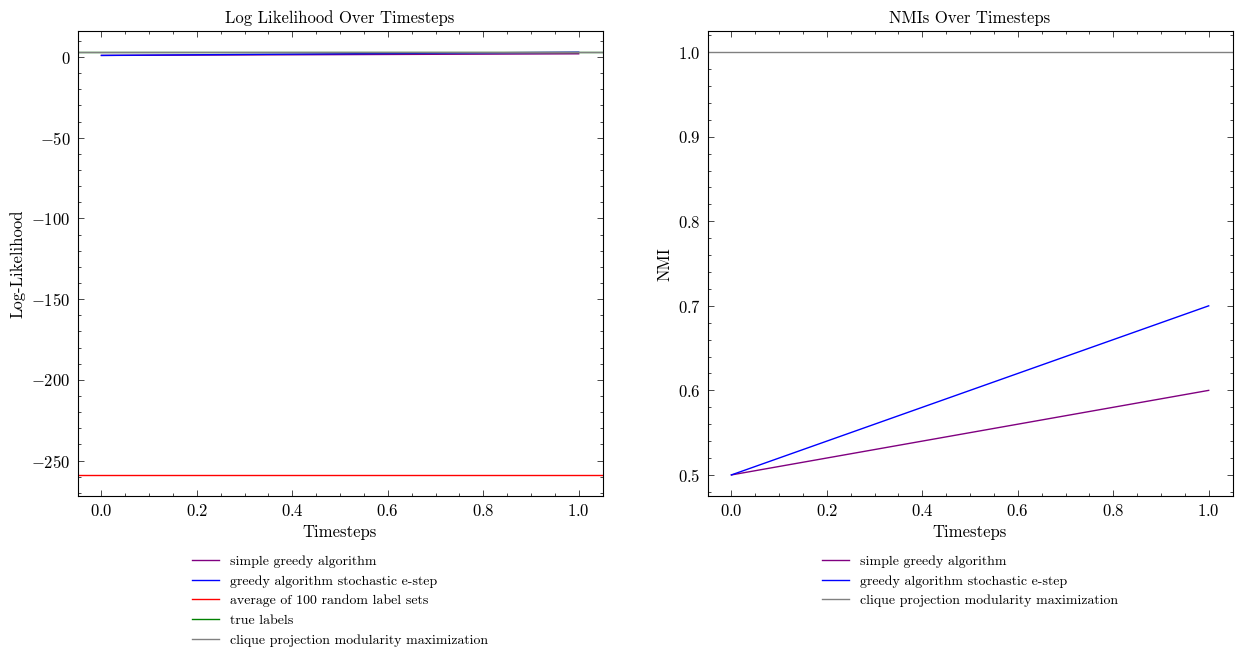

In [5]:
def dual_plot_algo_progress(g, total_likelihoods_greedy, total_likelihoods_e_step, nmis_greedy, nmis_e_step, true_label_log_likelihood, modularity_max_log_likelihood, modularity_max_nmi):
    

    random_average_likelihood = []
    for _ in range(100):
        null_labels = np.random.choice([0,1], size=len(g.get_labels()))
        random_average_likelihood.append(g.total_log_likelihood(true_theta, null_labels))
    ral = np.mean(random_average_likelihood)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

    ax1.plot(range(0, len(total_likelihoods_greedy)),total_likelihoods_greedy, label="simple greedy algorithm", color="purple")
    ax1.plot(range(0, len(total_likelihoods_e_step)),total_likelihoods_e_step, label="greedy algorithm stochastic e-step", color="blue")

    ax1.axhline(y=ral, color="red", label="average of 100 random label sets")
    ax1.axhline(y=true_label_log_likelihood, color="green", label="true labels")
    ax1.axhline(y=modularity_max_log_likelihood, color="grey", label="clique projection modularity maximization")

    ax1.set_title("Log Likelihood Over Timesteps")
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=1)
    ax1.set(xlabel = "Timesteps", ylabel = "Log-Likelihood")

    phi = phi = (1 + 5**0.5) / 2
    # ax1.set_aspect(phi)
    # ax2.set_aspect(phi)


    ax2.plot(range(0, len(nmis_greedy)),nmis_greedy, label="simple greedy algorithm", color="purple")
    ax2.plot(range(0, len(nmis_e_step)),nmis_e_step, label="greedy algorithm stochastic e-step", color="blue")

    ax2.axhline(y=modularity_max_nmi, color="grey", label="clique projection modularity maximization")

    ax2.set_title("NMIs Over Timesteps")
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=1)
    ax2.set(xlabel = "Timesteps", ylabel = "NMI")


dual_plot_algo_progress(g, [1,2], [1,3], [.5, .6], [.5,.7], 3, 3, 1)



In [6]:
# input is an instance of the class GH defined in poisson_hypergraph.py... output a tuple of lists of total likelihood and nmi indexed by timestep
def greedy_community_detection_algo(g, generate_likelihoods):
    total_likelihoods = []
    nmis = []

    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 1000
    step_num = 0
    while step_num < greedy_steps:
        delta_E = 0
        e_index = np.random.choice(range(1, len(g.get_edges())))
        
        v_index = np.random.choice(list(g.get_edges()[e_index]))

        canidate_f = []
        for f_index in range(e_index):
            if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                canidate_f.append(f_index)


        for f_index in canidate_f:
            delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) / len(canidate_f)
        
        if (delta_E > 0):
            null_labels[v_index] = 1 - null_labels[v_index]
            # print("swapped label of " + str(v_index) + " from edge " + str(e_index))

        step_num+=1

        # if (step_num % 25 == 0):
        if generate_likelihoods:
            total_likelihoods.append(g.total_log_likelihood(true_theta, null_labels))
            nmis.append(NMI(g.get_labels(), null_labels, g))
        
    # print("greedy labels likelihood: " + str(g.expected_log_likelihood_total(true_theta, null_labels)))
    # print("true labels likelihood: " + str(g.expected_log_likelihood_total(true_theta,true_labels)))
    # print(null_labels)
    # print(true_labels)
    if generate_likelihoods:
        return total_likelihoods, nmis
    else:
        return null_labels



# g = generate_graph_26_starting_nodes(true_theta, 25)
# likelihoods, nmis = greedy_community_detection_algo(g)
# plot_algo_progress(likelihoods, nmis, False, g.total_log_likelihood(true_theta, g.get_labels()))

In [7]:
# test on senate-like data

def generate_graph_100_nodes(true_theta, timesteps):
    true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er = true_theta
    H = xgi.Hypergraph([range(100)])
    H.set_node_attributes({0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:0,14:0,15:0,16:0,17:0,18:0,19:0,20:0,21:0,22:0,23:0,24:0,25:0,26:0,27:0,28:0,29:0,30:0,31:0,32:0,33:0,34:0,35:0,36:0,37:0,38:0,39:0,40:0,41:0,42:0,43:0,44:0,45:0,46:0,47:0,48:0,49:0,50:1,51:1,52:1,53:1,54:1,55:1,56:1,57:1,58:1,59:1,60:1,61:1,62:1,63:1,64:1,65:1,66:1,67:1,68:1,69:1,70:1,71:1,72:1,73:1,74:1,75:1,76:1,77:1,78:1,79:1,80:1,81:1,82:1,83:1,84:1,85:1,86:1,87:1,88:1,89:1,90:1,91:1,92:1,93:1,94:1,95:1,96:1,97:1,98:1,99:1}, name="label")
    g=GH(H, [0,1], true_p, true_q)
    g.add_hyperedge(timesteps, gamma_nu, gamma_nr, gamma_eu, gamma_er)

    return g


true_p = .9
true_q = .1
# gamma_nu is poisson weight for the distribution for number of like labeled novel nodes of choosen u novel nodes added
# gamma_nr is poisson weight for the distribution for number of opposite labeled nodes of choosen u novel nodes added
# gamma_eu is poisson weight for the distribution for number of like labeled nodes of choosen u external nodes added
# gamma_er is poisson weight for the distribution for number of opposite labeled nodes of choosen u external nodes added
gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

# should be in this order
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]
g = generate_graph_100_nodes(true_theta, 50)
LLs, nmis = greedy_community_detection_algo(g, True)

plot_algo_progress(LLs, nmis, False, g.total_log_likelihood(true_theta, g.get_labels()))

KeyboardInterrupt: 

In [ ]:
def greedy_community_detection_algo_with_posterior_prob(g, generate_likelihoods):
    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 1000
    step_num = 0

    # TODO remove, for testing
    total_likelihoods = []
    nmis = []
    while step_num < greedy_steps:
        delta_E = 0
        e_index = np.random.choice(range(1, len(g.get_edges())))
        v_index = np.random.choice(list(g.get_edges()[e_index]))

        new_labels = null_labels.copy()
        new_labels[v_index] = 1 - new_labels[v_index]

        f_probs = g.f_prob_array_given_e_array(e_index, true_theta, new_labels)

        canidate_f = []
        for f_index in range(e_index):
            if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                canidate_f.append(f_index)

        for f_index in canidate_f:
            delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) * f_probs[f_index]


        
        if (delta_E > 0):
            null_labels[v_index] = 1 - null_labels[v_index]
        
        # if (step_num % 25 == 0):
        if generate_likelihoods:
            total_likelihoods.append(g.total_log_likelihood(true_theta, null_labels))
            nmis.append(NMI(g.get_labels(), null_labels, g))

            
        step_num+=1

    if generate_likelihoods:
        return total_likelihoods, nmis
    else:
        return null_labels

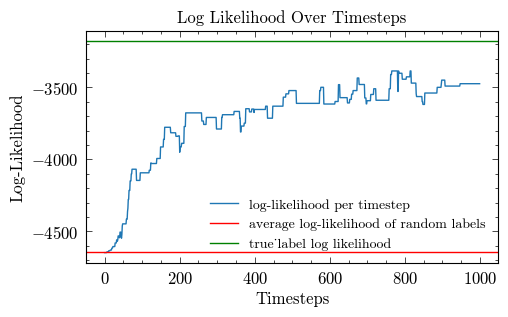

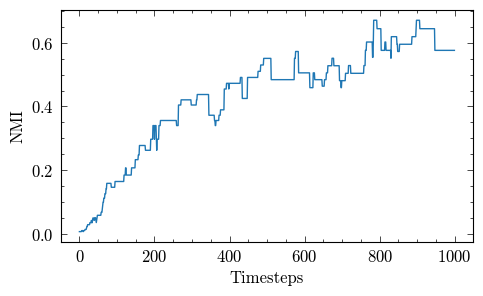

In [ ]:
LLs, nmis = greedy_community_detection_algo_with_posterior_prob(g, True)

plot_algo_progress(LLs, nmis, False, g.total_log_likelihood(true_theta, g.get_labels()))

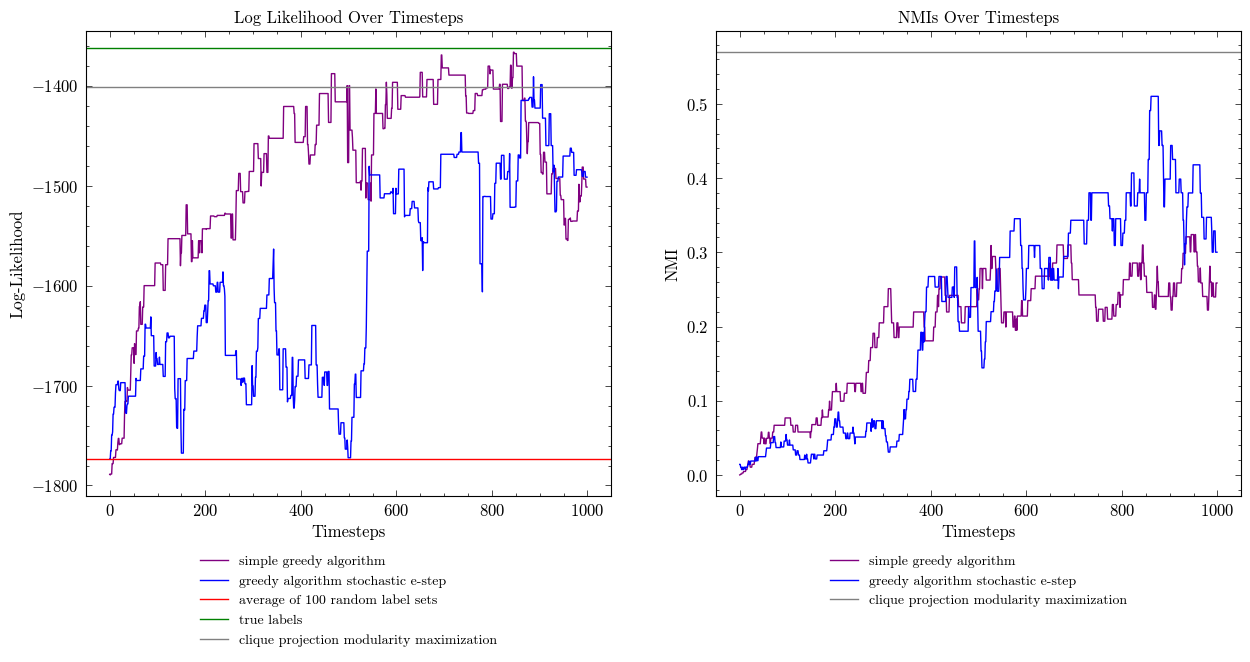

In [ ]:

true_p = .9
true_q = .1
gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

# should be in this order
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]
g = generate_graph_100_nodes(true_theta, 20)

greedy_LLs, greedy_nmis = greedy_community_detection_algo(g, True)
e_step_LLs, e_step_nmis = greedy_community_detection_algo_with_posterior_prob(g, True)

modularity_maximization_labels = clique_projection_modularity_maximization_algo(g)
mod_max_LL = g.total_log_likelihood(true_theta, modularity_maximization_labels)
mod_max_nmi = NMI(modularity_maximization_labels, g.get_labels(), g)

dual_plot_algo_progress(g, greedy_LLs, e_step_LLs, greedy_nmis, e_step_nmis, g.total_log_likelihood(true_theta, g.get_labels()), mod_max_LL, mod_max_nmi)

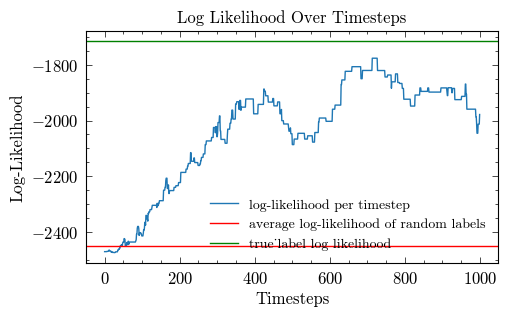

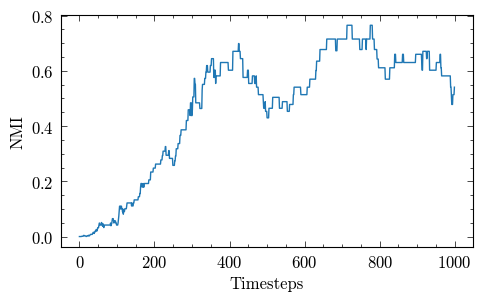

KeyboardInterrupt: 

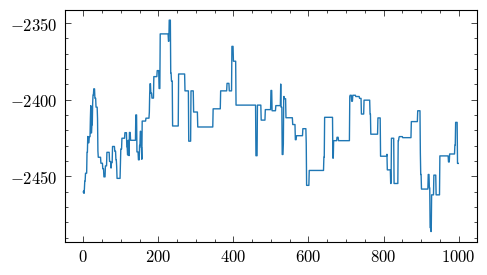

In [ ]:

true_p = .9
true_q = .1
gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

# should be in this order
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]
g = generate_graph_100_nodes(true_theta, 20)
LLs, nmis = greedy_community_detection_algo(g, True)

plot_algo_progress(LLs, nmis, False, g.total_log_likelihood(true_theta, g.get_labels()))

LLs, nmis = greedy_community_detection_algo_with_posterior_prob(g, True)

plot_algo_progress(LLs, nmis, False, g.total_log_likelihood(true_theta, g.get_labels()))

print(NMI(clique_projection_modularity_maximization_algo(g), g.get_labels(), g))

In [ ]:
# test the three algorithms average performance

greedy_end_LLs = []
greedy_fancy_end_LLs = []
projection_end_LLs = []
greedy_end_nmis = []
greedy_fancy_end_nmis = []
projection_end_nmis = []


for _ in range(100):
    true_p = .8
    true_q = .2
    gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

    # should be in this order
    true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]
    g = generate_graph_100_nodes(true_theta, 20)

    greedy_labels = greedy_community_detection_algo(g, False)
    greedy_end_LLs.append(g.total_log_likelihood(true_theta, greedy_labels))
    greedy_end_nmis.append(NMI(greedy_labels, g.get_labels(), g))

    greedy_labels = greedy_community_detection_algo_with_posterior_prob(g, False)
    greedy_fancy_end_LLs.append(g.total_log_likelihood(true_theta, greedy_labels))
    greedy_fancy_end_nmis.append(NMI(greedy_labels, g.get_labels(), g))

    projection_labels = clique_projection_modularity_maximization_algo(g)
    projection_end_LLs.append(g.total_log_likelihood(true_theta, projection_labels))
    projection_end_nmis.append(NMI(projection_labels, g.get_labels(), g))

    

In [ ]:
print("greedy algo mean LL: " + str(np.mean(greedy_end_LLs)))
print("greedy algo mean nmi: " + str(np.mean(greedy_end_nmis)))
print("greedy fancy algo mean LL: " + str(np.mean(greedy_fancy_end_LLs)))
print("greedy fancy algo mean LL: " + str(np.mean(greedy_fancy_end_nmis)))
print("clique projection modularity maximization: mean LL: " + str(np.mean(projection_end_LLs)))
print("clique projection modularity maximization: mean nmi: " + str(np.mean(projection_end_nmis)))

greedy algo mean LL: nan
greedy algo mean nmi: nan
greedy fancy algo mean LL: -1607.2570046335052
greedy fancy algo mean LL: 0.21585877619648589
clique projection modularity maximization: mean LL: nan
clique projection modularity maximization: mean nmi: nan


/home/fcataldo/labeled-hypercopy/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/fcataldo/labeled-hypercopy/.venv/lib64/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# now, consider an algorithm that picks the best run across 1000 steps for 10 runs


g = generate_graph_100_nodes(true_theta, 100)

def greedy_prob_diff_runs(g):
    run_labels = []
    for _ in range(1):
        run_labels.append(greedy_community_detection_algo_with_posterior_prob(g, False))

    run_LLs = []
    for i in range(1):
        run_LLs.append(g.total_log_likelihood(true_theta, run_labels[i]))

    return run_labels[np.argmax(run_LLs)]

print(NMI(g.get_labels(), greedy_prob_diff_runs(g), g))


0.02181509182026402


In [ ]:
clique = []
greedy = []

for _ in range(10):
    g = generate_graph_100_nodes(true_theta, 100)

    greedy.append(NMI(g.get_labels(), greedy_community_detection_algo_with_posterior_prob(g, False), g))
    clique.append(NMI(clique_projection_modularity_maximization_algo(g), g.get_labels(), g))

print(np.mean(greedy))
print(np.mean(clique))


0.29286238367520345
0.5542027808255916


In [ ]:

def generate_all_possible_label_sets(v_indexes):
    label_sets = []
    for i in range(1, len(v_indexes)+1):
        subsets = itertools.combinations(v_indexes, i)
        for set_ in subsets:
            label_sets.append(set_)
    
    return label_sets

def greedy_community_detection_algo_consider_all_labels(g, generate_likelihoods):
    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()
    # print(g.expected_log_likelihood_total(true_theta, null_labels))

    greedy_steps = 100
    step_num = 0

    # TODO remove, for testing
    total_likelihoods = []
    nmis = []
    while step_num < greedy_steps:
        delta_E = 0
        e_index = np.random.choice(range(0, len(g.get_edges())))
        f_weights = g.f_prob_array_given_e(e_index, true_theta, null_labels)

        canidate_f = []
        for f_index in range(e_index):
            if (len(g.get_edges()[e_index].intersection(g.get_edges()[f_index])) != 0):
                canidate_f.append(f_index)

        
        possible_label_changes = generate_all_possible_label_sets(g.get_edges()[e_index])
        max_delta = 0
        new_labels_best = null_labels

        for label_set in possible_label_changes:
            delta_E = 0
            new_labels = null_labels.copy()

            for v_index in label_set:
                for f_index in canidate_f:
                    delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, new_labels) * f_weights[f_index]
                
                new_labels[v_index] = 1 - new_labels[v_index]
            
            if delta_E > max_delta:
                max_delta = delta_E
                new_labels_best = new_labels

        null_labels = new_labels_best

        if generate_likelihoods:
            total_likelihoods.append(g.total_log_likelihood(true_theta, null_labels))
            nmis.append(NMI(g.get_labels(), null_labels, g))

            
        step_num+=1


        
        
    # print("greedy labels likelihood: " + str(g.expected_log_likelihood_total(true_theta, null_labels)))
    # print("true labels likelihood: " + str(g.expected_log_likelihood_total(true_theta,true_labels)))
    # print(null_labels)
    # print(true_labels)

    if generate_likelihoods:
        return total_likelihoods, nmis
    else:
        return null_labels


g = generate_graph_26_starting_nodes(true_theta, 10)
LLs, nmis = greedy_community_detection_algo_consider_all_labels(g, True)
plot_algo_progress(LLs, nmis, False, g.total_log_likelihood(true_theta, g.get_labels()))







KeyboardInterrupt: 

In [ ]:
def greedy_community_detection_algo_3_edge(g, generate_likelihoods):
    NUM_ES = 5

    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 2000
    step_num = 0

    # TODO remove, for testing
    total_likelihoods = []
    nmis = []
    while step_num < greedy_steps:
        delta_E = 0
        
        v_index = np.random.choice(list(range(len(g.get_labels()))))

        canidate_e = []
        for e_index in range(1, len(g.get_edges())):
            if v_index in g.get_edges()[e_index]:
                canidate_e.append(e_index)

        e_indexes = np.random.choice(canidate_e, min(NUM_ES, len(canidate_e)))

        new_labels = null_labels.copy()
        new_labels[v_index] = 1 - new_labels[v_index]

        for e_index in e_indexes:
            f_probs = g.f_prob_array_given_e(e_index, true_theta, new_labels)

            canidate_f = []
            for f_index in range(e_index):
                if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                    canidate_f.append(f_index)

            for f_index in canidate_f:
                delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) * f_probs[f_index]


        if (delta_E > 0):
            null_labels[v_index] = 1 - null_labels[v_index]
        
        # if (step_num % 25 == 0):
        if generate_likelihoods:
            total_likelihoods.append(g.total_log_likelihood(true_theta, null_labels))
            nmis.append(NMI(g.get_labels(), null_labels, g))

            
        step_num+=1

    if generate_likelihoods:
        return total_likelihoods, nmis
    else:
        return null_labels

In [ ]:
def greedy_community_detection_algo_3_label_3_node(g, generate_likelihoods):
    NUM_ES = 3
    NUM_US = 3

    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 2000
    step_num = 0

    # TODO remove, for testing
    total_likelihoods = []
    nmis = []
    while step_num < greedy_steps:
        delta_E = 0
        
        v_indexes = np.random.choice(list(range(len(g.get_labels()))), NUM_US)

        canidate_e = []
        for e_index in range(1, len(g.get_edges())):
            to_add = True
            for v_index in v_indexes:
                if v_index not in g.get_edges()[e_index]:
                    to_add = False
            
            if to_add:
                canidate_e.append(e_index)

        e_indexes = np.random.choice(canidate_e, min(NUM_ES, len(canidate_e)))

        new_labels = null_labels.copy()
        for v_index in v_indexes:
            new_labels[v_index] = 1 - new_labels[v_index]

        for e_index in e_indexes:
            f_probs = g.f_prob_array_given_e(e_index, true_theta, new_labels)

            canidate_f = []
            for f_index in range(e_index):
                if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                    canidate_f.append(f_index)

            for f_index in canidate_f:
                labels = null_labels.copy()
                for v_index in v_indexes:
                    delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) * f_probs[f_index]
                    labels[v_index] = 1 - labels[v_index]


        if (delta_E > 0):
            null_labels[v_index] = 1 - null_labels[v_index]
        
        # if (step_num % 25 == 0):
        if generate_likelihoods:
            total_likelihoods.append(g.total_log_likelihood(true_theta, null_labels))
            nmis.append(NMI(g.get_labels(), null_labels, g))

            
        step_num+=1

    if generate_likelihoods:
        return total_likelihoods, nmis
    else:
        return null_labels

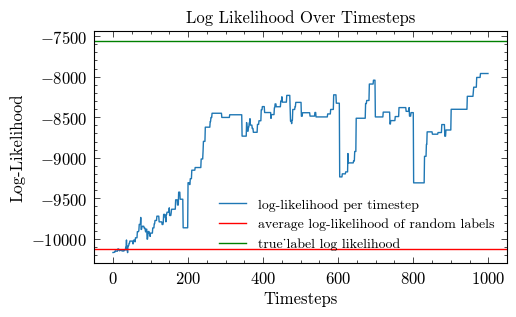

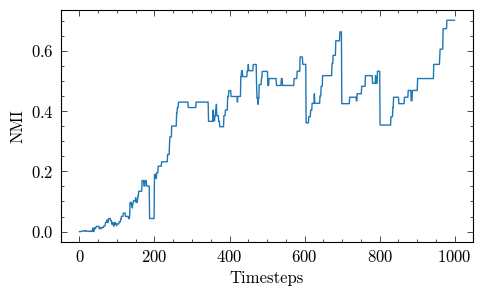

[9, 36, 37, 40, 42, 53, 75, 91, 135, 167, 187, 200, 344, 595, 604, 616, 699, 738, 801]
1.0


In [8]:
import random

def choose_k_similar_edges(k, g, e_index):
    e = g.get_edges()[e_index]
    n = len(e)

    other_es = []
    for f_index in range(1, e_index):
        f = g.get_edges()[f_index]

        if (len(f.intersection(e)) > n*.75):
            other_es.append(f_index)
    
    return np.random.choice(other_es, min(k, len(other_es)))

def greedy_algo_flip_all_labels(g, true_theta, likelihood_each_step):
    STEPS_PER_E = 1
    PROB_FLIP_STEP = .01
    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 1000
    step_num = 0

    LLs = []
    NMIs = []
    flip_steps = []
    max_likelihood = -np.inf
    max_likelihood_labels = None
    while step_num < greedy_steps:
        
        e_index = np.random.choice(range(1, len(g.get_edges())))
        f_probs = g.f_prob_array_given_e_array(e_index, true_theta, null_labels)

       
        new_labels = null_labels.copy()
        delta_E = 0

    
        if random.random() < PROB_FLIP_STEP:
            for v_index in g.get_edges()[e_index]:
                new_labels[v_index] = 1 - new_labels[v_index]

            canidate_f = []
            for f_index in range(e_index):
                if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                    canidate_f.append(f_index)
            
            tot = 0
            for f_index in canidate_f:
                temp = g.expected_log_likelihood_given_f(e_index, f_index, true_theta, new_labels) * f_probs[f_index]
                delta_E += temp
                tot += temp
                delta_E -= g.expected_log_likelihood_given_f(e_index, f_index, true_theta, null_labels) * f_probs[f_index]
                

            if (delta_E > abs(tot/5.0)):
                null_labels = new_labels
                flip_steps.append(step_num)
        else:
            v_index = np.random.choice(list(g.get_edges()[e_index]))
            
            new_labels[v_index] = 1 - new_labels[v_index]
            canidate_f = []
            for f_index in range(e_index):
                if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                    canidate_f.append(f_index)

            for f_index in canidate_f:
                delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) * f_probs[f_index]
            if (delta_E > 0):
                null_labels = new_labels
          
        if likelihood_each_step:
            LLs.append(g.total_log_likelihood(true_theta, null_labels))
            NMIs.append(NMI(true_labels, null_labels, g))

        step_num+=1

    if likelihood_each_step:
        return LLs, NMIs, flip_steps
    else:
        return null_labels
    
def greedy_algo_flip_all_labels_smart(g, true_theta, likelihood_each_step):
    STEPS_PER_E = 1
    ES_PER_E = 5
    PROB_FLIP_STEP = .2
    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 2000
    step_num = 0

    LLs = []
    NMIs = []
    flip_steps = []
    max_likelihood = -np.inf
    max_likelihood_labels = None
    while step_num < greedy_steps:
        
        e_index = np.random.choice(range(1, len(g.get_edges())))
        

       
        new_labels = null_labels.copy()
        delta_E = 0

    
        if random.random() < PROB_FLIP_STEP:
            for v_index in g.get_edges()[e_index]:
                new_labels[v_index] = 1 - new_labels[v_index]

            
            
            other_es = choose_k_similar_edges(ES_PER_E, g, e_index)

            tot = 0
            for e_index_consider in other_es:
                f_probs = g.f_prob_array_given_e_array(e_index_consider, true_theta, null_labels)
                canidate_f = []
                for f_index in range(e_index_consider):
                    if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index_consider])) != 0:
                        canidate_f.append(f_index)
                for f_index in canidate_f:
                    temp = g.expected_log_likelihood_given_f(e_index_consider, f_index, true_theta, new_labels) * f_probs[f_index]
                    delta_E += temp
                    tot += temp
                    delta_E -= g.expected_log_likelihood_given_f(e_index_consider, f_index, true_theta, null_labels) * f_probs[f_index]


            f_probs = g.f_prob_array_given_e_array(e_index, true_theta, null_labels)
            canidate_f = []
            for f_index in range(e_index):
                if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                    canidate_f.append(f_index)
            for f_index in canidate_f:
                temp = g.expected_log_likelihood_given_f(e_index, f_index, true_theta, new_labels) * f_probs[f_index]
                delta_E += temp
                tot += temp
                delta_E -= g.expected_log_likelihood_given_f(e_index, f_index, true_theta, null_labels) * f_probs[f_index]
                

            if (delta_E > 0):
                null_labels = new_labels
                flip_steps.append(step_num)
        else:
            v_index = np.random.choice(list(g.get_edges()[e_index]))
            
            new_labels[v_index] = 1 - new_labels[v_index]
            canidate_f = []
            for f_index in range(e_index):
                if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                    canidate_f.append(f_index)
            
            f_probs = g.f_prob_array_given_e_array(e_index, true_theta, null_labels)

            for f_index in canidate_f:
                delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) * f_probs[f_index]
            if (delta_E > 0):
                null_labels = new_labels
          
        if likelihood_each_step:
            LLs.append(g.total_log_likelihood(true_theta, null_labels))
            NMIs.append(NMI(true_labels, null_labels, g))

        step_num+=1

    if likelihood_each_step:
        return LLs, NMIs, flip_steps
    else:
        return null_labels

true_p = .9
true_q = .1
gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

# should be in this order
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]

g = generate_graph_100_nodes(true_theta, 100)

LLs, NMIs, flip_steps = greedy_algo_flip_all_labels_smart(g, true_theta, True)
    
plot_algo_progress(LLs, NMIs, False, g.total_log_likelihood(true_theta, g.get_labels()))

print(flip_steps)
clique_projection_labels = clique_projection_modularity_maximization_algo(g)
print(NMI(clique_projection_labels, g.get_labels(), g))

more timesteps, try wrong parameters, senate bills

In [ ]:
greedy_end_LLs = []
greedy_fancy_end_LLs = []
projection_end_LLs = []
greedy_end_nmis = []
greedy_fancy_end_nmis = []
projection_end_nmis = []
greedy_3_label_LLs = []
greedy_3_label_nmis = []
greedy_3_label_warm_LLs = []
greedy_3_label_warm_nmis = []


for _ in range(100):
    true_p = .9
    true_q = .1
    gamma_nu, gamma_nr, gamma_eu, gamma_er = .01, .01, 1, 0.25

    # should be in this order
    true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]
    g = generate_graph_26_starting_nodes(true_theta, 50)

    greedy_labels = greedy_community_detection_weighted_e(g, False)
    greedy_end_LLs.append(g.total_log_likelihood(true_theta, greedy_labels))
    greedy_end_nmis.append(NMI(greedy_labels, g.get_labels(), g))

    greedy_labels = greedy_community_detection_algo_with_posterior_prob(g, False)
    greedy_fancy_end_LLs.append(g.total_log_likelihood(true_theta, greedy_labels))
    greedy_fancy_end_nmis.append(NMI(greedy_labels, g.get_labels(), g))

    greedy_labels = greedy_community_detection_algo_3_edge(g, False)
    greedy_3_label_LLs.append(g.total_log_likelihood(true_theta, greedy_labels))
    greedy_3_label_nmis.append(NMI(greedy_labels, g.get_labels(), g))

    projection_labels = clique_projection_modularity_maximization_algo(g)
    projection_end_LLs.append(g.total_log_likelihood(true_theta, projection_labels))
    projection_end_nmis.append(NMI(projection_labels, g.get_labels(), g))




In [ ]:
print("greedy algo mean LL: " + str(np.mean(greedy_end_LLs)))
print("greedy algo mean nmi: " + str(np.mean(greedy_end_nmis)))
print("greedy fancy algo mean LL: " + str(np.mean(greedy_fancy_end_LLs)))
print("greedy fancy algo mean LL: " + str(np.mean(greedy_fancy_end_nmis)))
print("greedy 3-label algo mean LL: " + str(np.mean(greedy_3_label_LLs)))
print("greedy 3-label algo mean LL: " + str(np.mean(greedy_3_label_nmis)))
print("clique projection modularity maximization: mean LL: " + str(np.mean(projection_end_LLs)))
print("clique projection modularity maximization: mean nmi: " + str(np.mean(projection_end_nmis)))

greedy algo mean LL: -883.009846183316
greedy algo mean nmi: 0.39384549101227534
greedy fancy algo mean LL: -904.8039001843878
greedy fancy algo mean LL: 0.3506114844334599
greedy 3-label algo mean LL: -883.9825509540989
greedy 3-label algo mean LL: 0.41689352079730596
clique projection modularity maximization: mean LL: -849.2513321659736
clique projection modularity maximization: mean nmi: 0.7333302614660648


In [ ]:
import random

def greedy_community_detection_weighted_e(g, generate_likelihoods):
    null_labels = np.random.choice([0,1], size=len(g.get_labels()))
    true_labels = g.get_labels()

    greedy_steps = 10000
    step_num = 0


    # TODO remove, for testing
    total_likelihoods = []
    nmis = []
    while step_num < greedy_steps:
        delta_E = 0

        weights = list(range(1, len(g.get_edges())))

        # Pick one item weighted by index
        e_index = random.choices(range(1, len(g.get_edges())), weights=weights, k=1)[0]
        
        # e_index = np.random.choice(range(1, len(g.get_edges())), prob_array)
        v_index = np.random.choice(list(g.get_edges()[e_index]))

        new_labels = null_labels.copy()
        new_labels[v_index] = 1 - new_labels[v_index]

        f_probs = g.f_prob_array_given_e_array(e_index, true_theta, new_labels)

        canidate_f = []
        for f_index in range(e_index):
            if len(g.get_edges()[f_index].intersection(g.get_edges()[e_index])) != 0:
                canidate_f.append(f_index)

        for f_index in canidate_f:
            delta_E += g.greedy_expectation_step_given_f(v_index, f_index, e_index, true_theta, null_labels) * f_probs[f_index]


        
        if (delta_E > 0):
            null_labels[v_index] = 1 - null_labels[v_index]
        
        # if (step_num % 25 == 0):
        if generate_likelihoods:
            total_likelihoods.append(g.total_log_likelihood(true_theta, null_labels))
            nmis.append(NMI(g.get_labels(), null_labels, g))

            
        step_num+=1

    if generate_likelihoods:
        return total_likelihoods, nmis
    else:
        return null_labels